In [1]:
!pip install pandas matplotlib scikit-learn

'C:\Users\pasan\AppData\Local\Programs\Python\Python311\Scripts\pip.exe' ha sido bloqueado por la directiva de Device Guard de su organizaci�n.
Ponte en contacto con el personal de soporte t�cnico para obtener m�s informaci�n.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [5]:
paises = pd.read_csv("Principales_Paises_Flujo_Carga_Canal_Panama.csv")
buques = pd.read_csv("Trafico_Buques_Segmento_Mercado_Canal_Panama.csv")

print("Archivo 1 - Países:")
print(paises.head())

print("\nArchivo 2 - Buques:")
print(buques.head())

Archivo 1 - Países:
             País     Origen   Destino  Costa a Costa      Total  \
0  Estados Unidos  116459579  66947531      1917157.0  185324266   
1           China   28473050  24997237            NaN   53470287   
2           Japón    6360992  28178263            NaN   34539255   
3           Chile   12230311  11189165            NaN   23419476   
4   Corea del Sur   11649158  10486501            NaN   22135659   

   Total Menos Carga de Costa a Costa      %  
0                           183407109  69.9%  
1                            53470287  20.4%  
2                            34539255  13.2%  
3                            23419476   8.9%  
4                            22135659   8.4%  

Archivo 2 - Buques:
       Segmento de Mercado  Tránsitos 2024  Tránsitos 2025  \
0        Portacontenedores            2773            2893   
1  Gas Licuado de Petróleo            1561            1805   
2               Graneleros            1278            2230   
3      Portavehículo

In [6]:
# Quitar la fila "Total" del archivo de buques
buques = buques[buques['Segmento de Mercado'] != 'Total'].copy()

# La columna % viene como texto "15.63%", la convertimos a número 15.63
buques['% Diferencia Tránsitos'] = (buques['% Diferencia Tránsitos']
                                     .str.replace('%','')
                                     .str.strip()
                                     .astype(float))

# Rellenar celdas vacías con 0
buques['Toneladas Largas de Carga 2024'] = buques['Toneladas Largas de Carga 2024'].fillna(0)
buques['Toneladas Largas de Carga 2025'] = buques['Toneladas Largas de Carga 2025'].fillna(0)
paises['Costa a Costa'] = paises['Costa a Costa'].fillna(0)

print("Datos listos:")
print(buques[['Segmento de Mercado','Tránsitos 2024','Tránsitos 2025']].to_string())

Datos listos:
        Segmento de Mercado  Tránsitos 2024  Tránsitos 2025
0         Portacontenedores            2773            2893
1   Gas Licuado de Petróleo            1561            1805
2                Graneleros            1278            2230
3       Portavehículos/RoRo             783             871
4                  Químicos            1808            2218
5                Petroleros             422             444
6                 Pasajeros             205             214
7       Gas Natural Licuado             115              61
8             Carga General             287             463
9              Refrigerados             436             516
10                    Otros            1572            1689


In [7]:
# Calculamos cuántos barcos más (o menos) pasaron en 2025 vs 2024
buques['Cambio'] = buques['Tránsitos 2025'] - buques['Tránsitos 2024']

print("Tendencia por segmento:")
print(buques[['Segmento de Mercado','Tránsitos 2024','Tránsitos 2025','Cambio','% Diferencia Tránsitos']].to_string())

Tendencia por segmento:
        Segmento de Mercado  Tránsitos 2024  Tránsitos 2025  Cambio  % Diferencia Tránsitos
0         Portacontenedores            2773            2893     120                    4.33
1   Gas Licuado de Petróleo            1561            1805     244                   15.63
2                Graneleros            1278            2230     952                   74.49
3       Portavehículos/RoRo             783             871      88                   11.24
4                  Químicos            1808            2218     410                   22.68
5                Petroleros             422             444      22                    5.21
6                 Pasajeros             205             214       9                    4.39
7       Gas Natural Licuado             115              61     -54                  -46.96
8             Carga General             287             463     176                   61.32
9              Refrigerados             436             

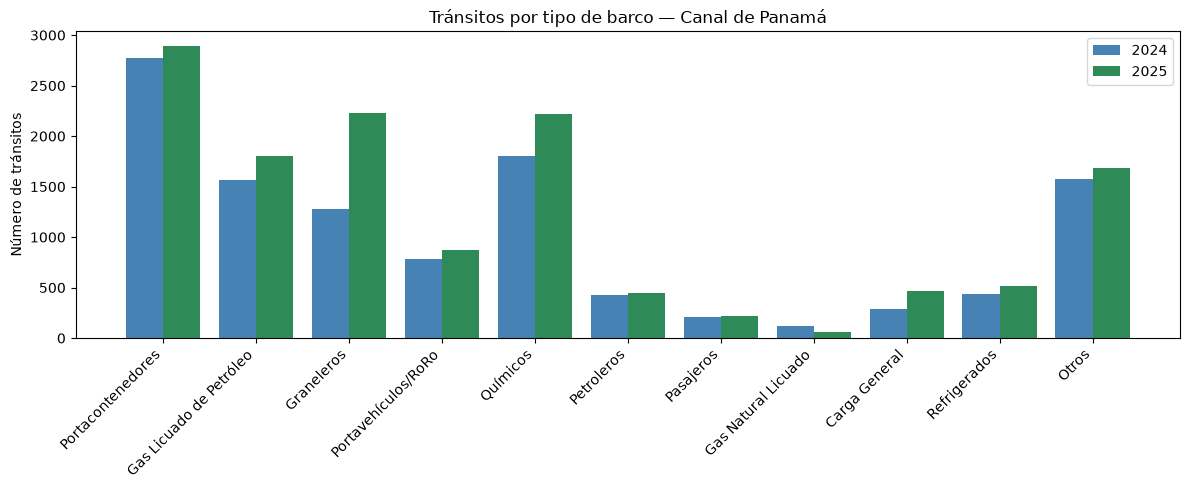

In [8]:
plt.figure(figsize=(12, 5))

x = range(len(buques))
plt.bar([i - 0.2 for i in x], buques['Tránsitos 2024'], width=0.4, label='2024', color='steelblue')
plt.bar([i + 0.2 for i in x], buques['Tránsitos 2025'], width=0.4, label='2025', color='seagreen')

plt.xticks(x, buques['Segmento de Mercado'], rotation=45, ha='right')
plt.ylabel('Número de tránsitos')
plt.title('Tránsitos por tipo de barco — Canal de Panamá')
plt.legend()
plt.tight_layout()
plt.savefig('tendencia_transitos.png')
plt.show()

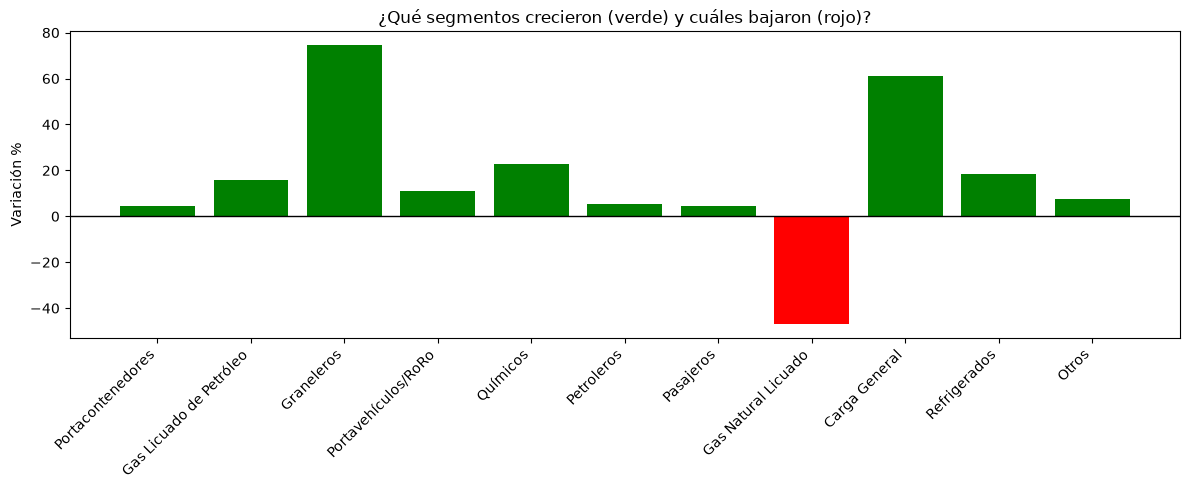

In [9]:
colores = ['green' if c > 0 else 'red' for c in buques['Cambio']]

plt.figure(figsize=(12, 5))
plt.bar(buques['Segmento de Mercado'], buques['% Diferencia Tránsitos'], color=colores)
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Variación %')
plt.title('¿Qué segmentos crecieron (verde) y cuáles bajaron (rojo)?')
plt.tight_layout()
plt.savefig('variacion_tendencia.png')
plt.show()

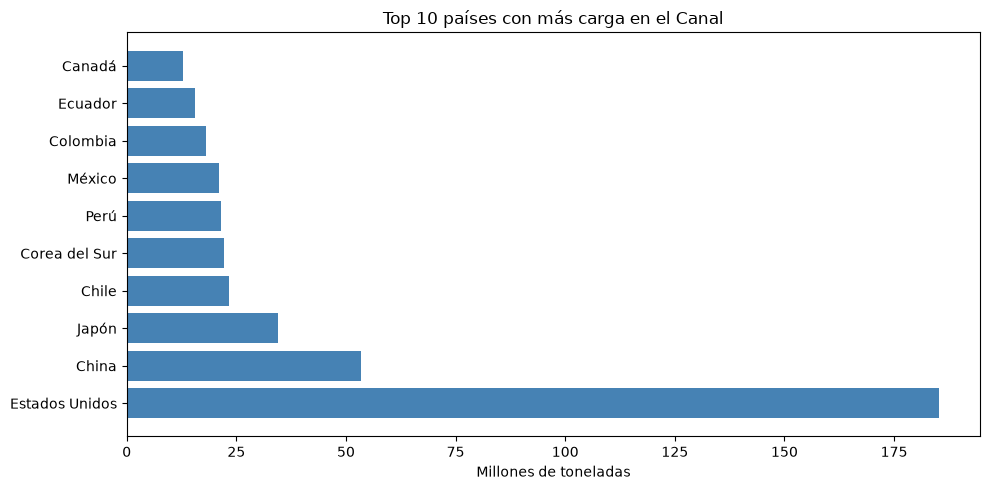

In [10]:
top = paises.nlargest(10, 'Total')

plt.figure(figsize=(10, 5))
plt.barh(top['País'], top['Total'] / 1_000_000, color='steelblue')
plt.xlabel('Millones de toneladas')
plt.title('Top 10 países con más carga en el Canal')
plt.tight_layout()
plt.savefig('top_paises.png')
plt.show()

In [11]:
# El modelo necesita:
# X = datos que le damos como pistas (tránsitos 2024)
# y = lo que queremos predecir (tránsitos 2025)

X = buques[['Tránsitos 2024']].values  # pistas
y = buques['Tránsitos 2025'].values    # respuesta correcta

print("Pistas (X) — Tránsitos 2024:")
print(X.flatten())

print("\nRespuesta (y) — Tránsitos 2025:")
print(y)

Pistas (X) — Tránsitos 2024:
[2773 1561 1278  783 1808  422  205  115  287  436 1572]

Respuesta (y) — Tránsitos 2025:
[2893 1805 2230  871 2218  444  214   61  463  516 1689]


In [12]:
modelo = LinearRegression()
modelo.fit(X, y)

print("Modelo entrenado!")
print(f"Por cada tránsito en 2024, el modelo espera {modelo.coef_[0]:.2f} tránsitos en 2025")

Modelo entrenado!
Por cada tránsito en 2024, el modelo espera 1.11 tránsitos en 2025


In [13]:
predicciones_2025 = modelo.predict(X)

print("Comparación Real vs Predicho:")
print(f"{'Segmento':<25} {'Real 2025':>10} {'Predicho':>10} {'Error':>8}")
print("-" * 55)

for i, seg in enumerate(buques['Segmento de Mercado']):
    real  = int(y[i])
    pred  = int(predicciones_2025[i])
    error = real - pred
    print(f"{seg:<25} {real:>10,} {pred:>10,} {error:>+8,}")

Comparación Real vs Predicho:
Segmento                   Real 2025   Predicho    Error
-------------------------------------------------------
Portacontenedores              2,893      3,166     -273
Gas Licuado de Petróleo        1,805      1,818      -13
Graneleros                     2,230      1,503     +727
Portavehículos/RoRo              871        952      -81
Químicos                       2,218      2,093     +125
Petroleros                       444        551     -107
Pasajeros                        214        309      -95
Gas Natural Licuado               61        209     -148
Carga General                    463        400      +63
Refrigerados                     516        566      -50
Otros                          1,689      1,830     -141


In [16]:
# Tomamos los tránsitos de 2025 como punto de partida para predecir 2026
X_2026 = buques[['Tránsitos 2025']].values
predicciones_2026 = modelo.predict(X_2026)

print("Predicción de tránsitos para 2026:")
print(f"{'Segmento':<25} {'2024':>8} {'2025':>8} {'2026 est.':>10}")
print("-" * 55)

for i, seg in enumerate(buques['Segmento de Mercado']):
    t24 = int(buques['Tránsitos 2024'].iloc[i])
    t25 = int(buques['Tránsitos 2025'].iloc[i])
    t26 = int(predicciones_2026[i])
    print(f"{seg:<25} {t24:>8,} {t25:>8,} {t26:>10,}")

print(f"\nTotal estimado 2026: {int(predicciones_2026.sum()):,} tránsitos")

Predicción de tránsitos para 2026:
Segmento                      2024     2025  2026 est.
-------------------------------------------------------
Portacontenedores            2,773    2,893      3,300
Gas Licuado de Petróleo      1,561    1,805      2,089
Graneleros                   1,278    2,230      2,562
Portavehículos/RoRo            783      871      1,050
Químicos                     1,808    2,218      2,549
Petroleros                     422      444        575
Pasajeros                      205      214        319
Gas Natural Licuado            115       61        149
Carga General                  287      463        596
Refrigerados                   436      516        655
Otros                        1,572    1,689      1,960

Total estimado 2026: 15,811 tránsitos


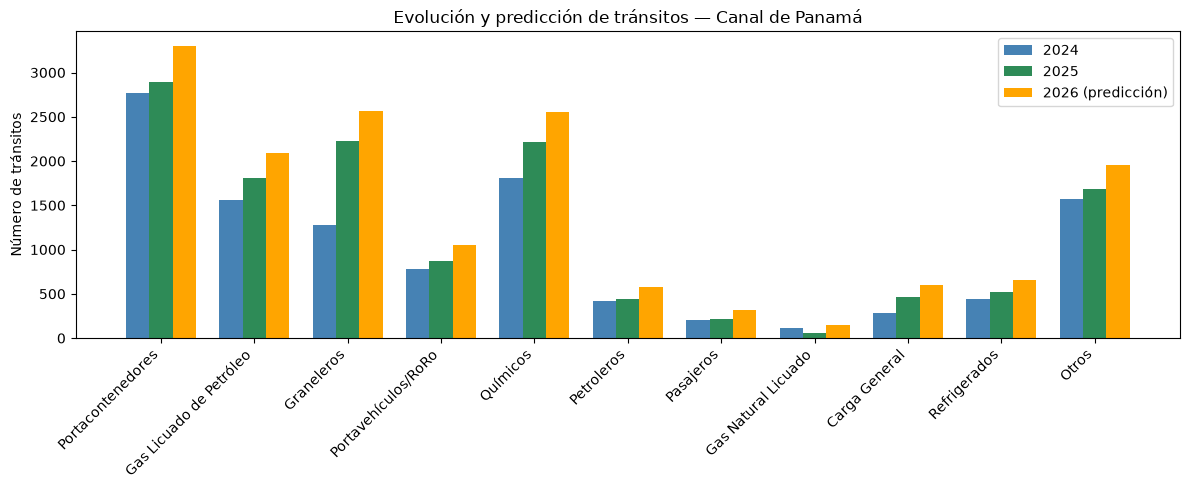

In [17]:
plt.figure(figsize=(12, 5))

x = range(len(buques))
plt.bar([i - 0.25 for i in x], buques['Tránsitos 2024'], width=0.25, label='2024', color='steelblue')
plt.bar([i        for i in x], buques['Tránsitos 2025'], width=0.25, label='2025', color='seagreen')
plt.bar([i + 0.25 for i in x], predicciones_2026,        width=0.25, label='2026 (predicción)', color='orange')

plt.xticks(x, buques['Segmento de Mercado'], rotation=45, ha='right')
plt.ylabel('Número de tránsitos')
plt.title('Evolución y predicción de tránsitos — Canal de Panamá')
plt.legend()
plt.tight_layout()
plt.savefig('prediccion_2026.png')
plt.show()